In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv("StressLevelDataset.csv")

In [4]:
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [16]:
df.isna().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [18]:
df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,2.737273,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,1.406171,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [19]:
for col in df.columns:
    valores_unicos = df[col].unique()
    valores_negativos = df.loc[(df[col] < 0), col]
    print(f"{col}: {valores_unicos} | valores negativos: {valores_negativos.size}\n")

anxiety_level: [14 15 12 16 20  4 17 13  6  5  9  2 11  7 21  3 18  0  8  1 19 10] | valores negativos: 0

self_esteem: [20  8 18 12 28 13 26  3 22 15 23 21 25  1 27  5  6  9 29 30  4 19 16  2
  0 14  7 17 24 11 10] | valores negativos: 0

mental_health_history: [0 1] | valores negativos: 0

depression: [11 15 14  7 21  6 22 12 27 25  8 24  3  1  0  5 26 20 10  9  2 16  4 13
 18 23 17 19] | valores negativos: 0

headache: [2 5 4 3 1 0] | valores negativos: 0

blood_pressure: [1 3 2] | valores negativos: 0

sleep_quality: [2 1 5 4 3 0] | valores negativos: 0

breathing_problem: [4 2 3 1 5 0] | valores negativos: 0

noise_level: [2 3 4 1 0 5] | valores negativos: 0

living_conditions: [3 1 2 4 5 0] | valores negativos: 0

safety: [3 2 4 1 5 0] | valores negativos: 0

basic_needs: [2 3 1 4 5 0] | valores negativos: 0

academic_performance: [3 1 2 4 5 0] | valores negativos: 0

study_load: [2 4 3 5 1 0] | valores negativos: 0

teacher_student_relationship: [3 1 2 4 5 0] | valores negativos

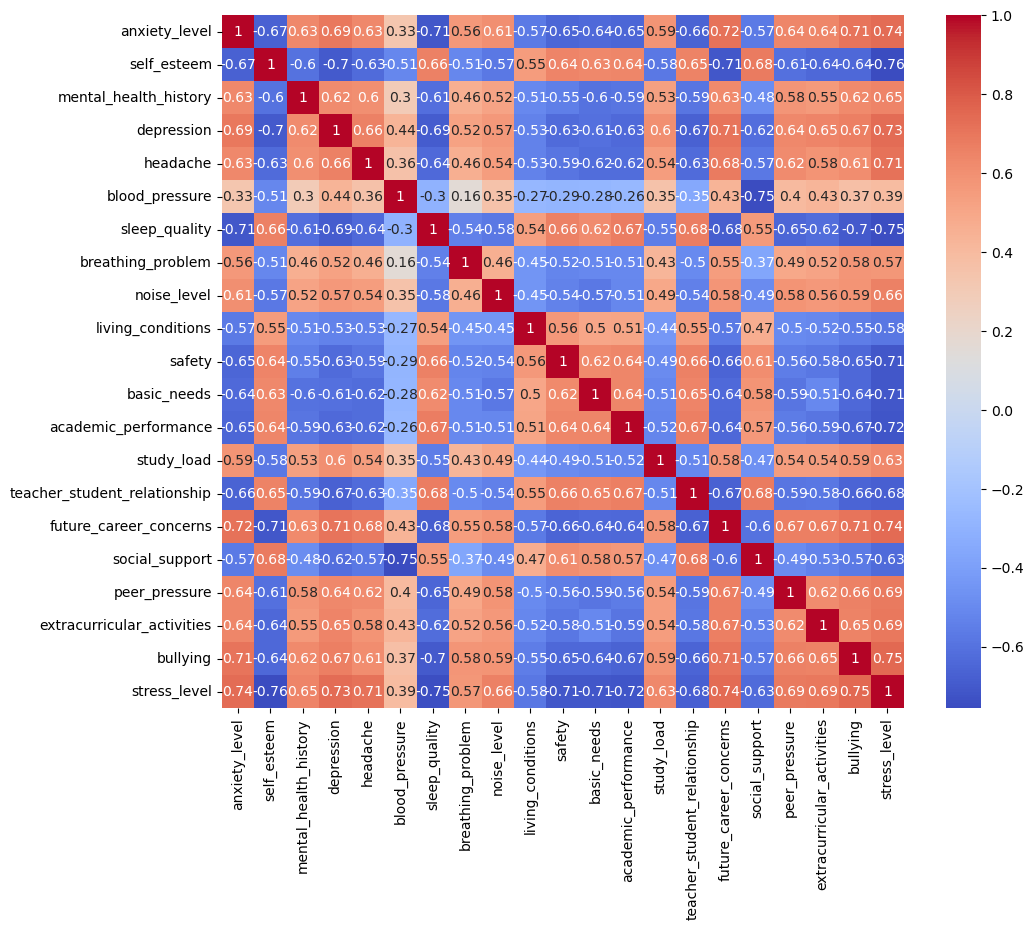

In [20]:
cor = df.corr()
plt.figure(figsize= (11,9))
sns.heatmap(cor, annot = True, cmap = 'coolwarm')
plt.show()

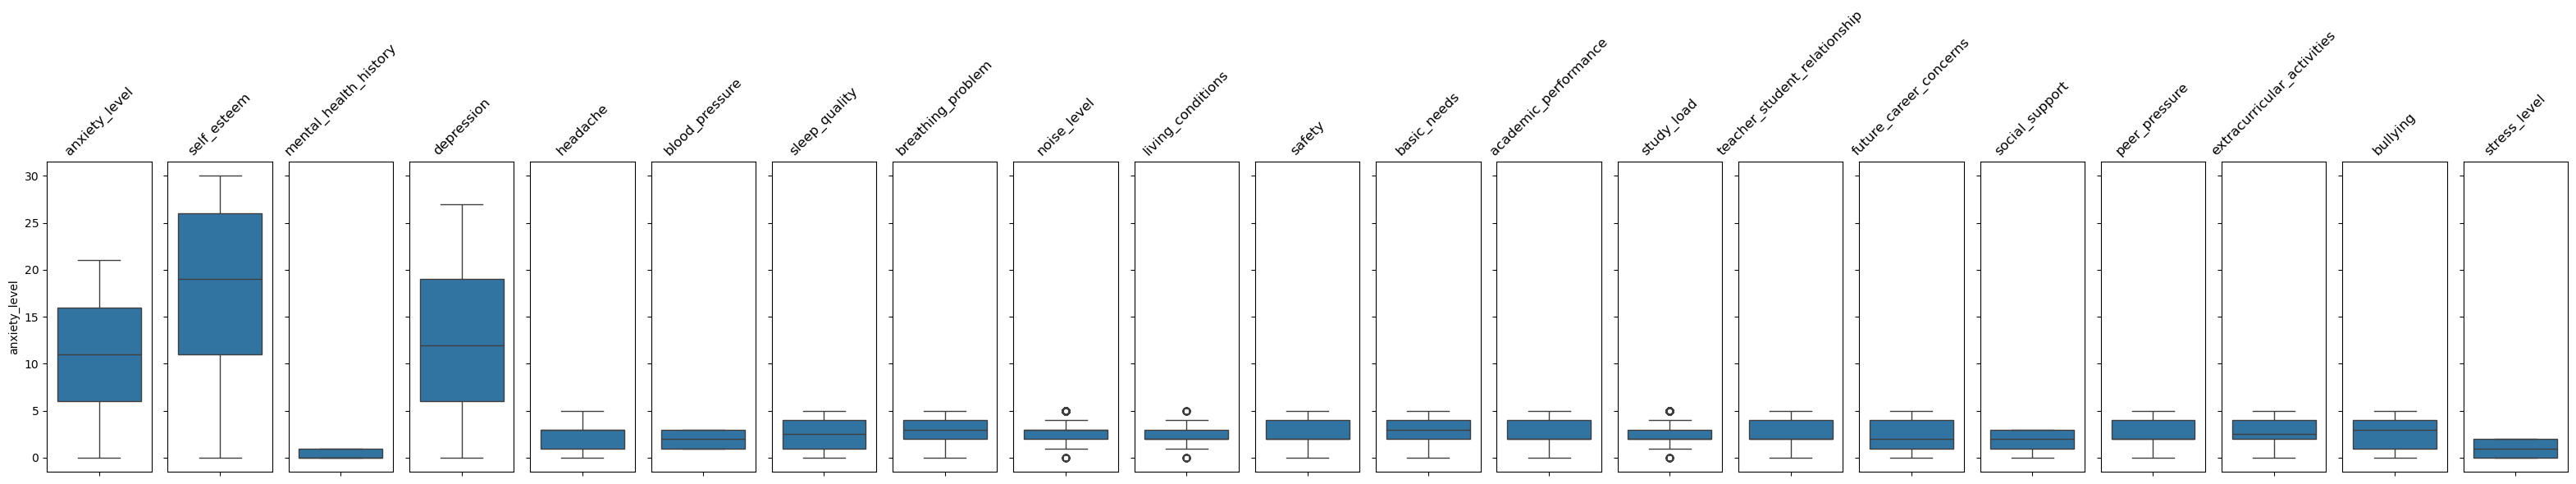

In [21]:
fig, axes = plt.subplots(1,21,figsize=(len(df.columns)*1.5, 6), sharey=True)

for i, col in enumerate(df.columns):
    sns.boxplot(df[col], ax = axes[i])
    axes[i].set_title(col, rotation = 45)
    

plt.tight_layout()
plt.show()

In [22]:
mean_noise_level = df['noise_level'].mean()
std_noise_level = df['noise_level'].std()
coeficiente_noise_level = (std_noise_level / mean_noise_level) * 100

mean_living_conditions = df['living_conditions'].mean()
std_living_conditions = df['living_conditions'].std()
coeficiente_living_conditions = (std_living_conditions / mean_living_conditions) * 100

mean_study_load = df['study_load'].mean()
std_study_load = df['study_load'].std()
coeficiente_study_load = (std_study_load / mean_study_load) * 100

print(f"noise_level - Coeficiente de Variação: {coeficiente_noise_level}%")
print(f"living_conditions - Coeficiente de Variação: {coeficiente_living_conditions}%")
print(f"study_load - Coeficiente de Variação: {coeficiente_study_load}%")

noise_level - Coeficiente de Variação: 50.13519323687107%
living_conditions - Coeficiente de Variação: 44.445079613371355%
study_load - Coeficiente de Variação: 50.185822293863055%


In [23]:
mediana_noise_leve = df['noise_level'].median()
mediana_living_conditions = df['living_conditions'].median()
mediana_study_load = df['study_load'].median()

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
 

X = df[["anxiety_level", "future_career_concerns", "bullying", "depression","sleep_quality","peer_pressure"]]
y = df["stress_level"]
 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

MSE: 0.15
R²: 0.78


In [25]:
grupoBullying = df[df['bullying']==1]['stress_level']
grupoNbullying = df[df['bullying']==0]['stress_level']

t_stat,p_value = stats.ttest_ind(grupoBullying,grupoNbullying,equal_var=False)
print(f"T = {t_stat:.2f}, p={p_value:.2f}")

ic = stats.t.interval(0.95,len(grupoBullying)-1,loc = grupoBullying.mean(), scale =stats.sem(grupoBullying) )

print(f"Ic de 95% do grupo que sofreu bullying e: {ic}")

T = -5.93, p=0.00
Ic de 95% do grupo que sofreu bullying e: (0.06650147741288567, 0.16036419422890538)


In [5]:
# Análise exploratória das variáveis para os testes de hipótese
print("=== ANÁLISE DAS VARIÁVEIS ===")
print("\n1. Variável sleep_quality:")
print(f"Valores únicos: {sorted(df['sleep_quality'].unique())}")
print(f"Contagem por categoria:\n{df['sleep_quality'].value_counts().sort_index()}")

print("\n2. Variável stress_level:")
print(f"Min: {df['stress_level'].min()}, Max: {df['stress_level'].max()}")
print(f"Média: {df['stress_level'].mean():.2f}, Desvio padrão: {df['stress_level'].std():.2f}")

print("\n3. Variável study_load:")
print(f"Min: {df['study_load'].min()}, Max: {df['study_load'].max()}")
print(f"Média: {df['study_load'].mean():.2f}, Desvio padrão: {df['study_load'].std():.2f}")

print("\n4. Correlação inicial entre stress_level e study_load:")
correlacao_inicial = df['stress_level'].corr(df['study_load'])
print(f"Correlação de Pearson: {correlacao_inicial:.4f}")

=== ANÁLISE DAS VARIÁVEIS ===

1. Variável sleep_quality:
Valores únicos: [0, 1, 2, 3, 4, 5]
Contagem por categoria:
sleep_quality
0     34
1    328
2    188
3    170
4    188
5    192
Name: count, dtype: int64

2. Variável stress_level:
Min: 0, Max: 2
Média: 1.00, Desvio padrão: 0.82

3. Variável study_load:
Min: 0, Max: 5
Média: 2.62, Desvio padrão: 1.32

4. Correlação inicial entre stress_level e study_load:
Correlação de Pearson: 0.6342


In [6]:
from scipy.stats import f_oneway
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("HIPÓTESE 2: ANOVA - Diferença de stress_level entre níveis de sleep_quality")
print("="*60)

# Separar grupos por sleep_quality
grupos_sleep = []
for i in sorted(df['sleep_quality'].unique()):
    grupo = df[df['sleep_quality'] == i]['stress_level']
    grupos_sleep.append(grupo)
    print(f"Sleep Quality {i}: n={len(grupo)}, média={grupo.mean():.3f}, std={grupo.std():.3f}")

print("\nHipóteses:")
print("H0: Todas as médias de stress_level são iguais entre os níveis de sleep_quality")
print("H1: Pelo menos uma média de stress_level é diferente")

# Teste ANOVA
f_stat, p_value_anova = f_oneway(*grupos_sleep)

print(f"\nResultados da ANOVA:")
print(f"Estatística F: {f_stat:.4f}")
print(f"p-valor: {p_value_anova:.6f}")
print(f"Nível de significância: 0.05")

if p_value_anova < 0.05:
    print("✅ RESULTADO: Rejeitamos H0 - Há diferença significativa entre as médias")
    print("   Conclusão: O nível de qualidade do sono afeta significativamente o stress_level")
else:
    print("❌ RESULTADO: Não rejeitamos H0 - Não há evidência de diferença significativa")
    print("   Conclusão: Não há evidência que o nível de qualidade do sono afete o stress_level")

HIPÓTESE 2: ANOVA - Diferença de stress_level entre níveis de sleep_quality
Sleep Quality 0: n=34, média=0.971, std=0.870
Sleep Quality 1: n=328, média=1.933, std=0.334
Sleep Quality 2: n=188, média=0.957, std=0.307
Sleep Quality 3: n=170, média=0.988, std=0.392
Sleep Quality 4: n=188, média=0.186, std=0.499
Sleep Quality 5: n=192, média=0.240, std=0.601

Hipóteses:
H0: Todas as médias de stress_level são iguais entre os níveis de sleep_quality
H1: Pelo menos uma média de stress_level é diferente

Resultados da ANOVA:
Estatística F: 517.1504
p-valor: 0.000000
Nível de significância: 0.05
✅ RESULTADO: Rejeitamos H0 - Há diferença significativa entre as médias
   Conclusão: O nível de qualidade do sono afeta significativamente o stress_level


In [7]:
from scipy.stats import pearsonr

print("\n" + "="*60)
print("HIPÓTESE 3: Correlação de Pearson - stress_level vs study_load")
print("="*60)

print("Hipóteses:")
print("H0: ρ = 0 (não há correlação linear entre stress_level e study_load)")
print("H1: ρ > 0 (há correlação positiva significativa)")

# Teste de correlação de Pearson
correlation_coef, p_value_corr = pearsonr(df['stress_level'], df['study_load'])

print(f"\nResultados da Correlação de Pearson:")
print(f"Coeficiente de correlação (r): {correlation_coef:.4f}")
print(f"p-valor: {p_value_corr:.10f}")
print(f"Nível de significância: 0.05")

# Como estamos testando correlação positiva (teste unilateral), dividimos p-valor por 2
p_value_unilateral = p_value_corr / 2

print(f"p-valor (teste unilateral): {p_value_unilateral:.10f}")

# Interpretação da força da correlação
if abs(correlation_coef) < 0.3:
    forca = "fraca"
elif abs(correlation_coef) < 0.7:
    forca = "moderada"
else:
    forca = "forte"

print(f"\nInterpretação da correlação:")
print(f"- Magnitude: {forca} (|r| = {abs(correlation_coef):.4f})")
print(f"- Direção: {'positiva' if correlation_coef > 0 else 'negativa'}")

if p_value_unilateral < 0.05 and correlation_coef > 0:
    print("✅ RESULTADO: Rejeitamos H0 - Há correlação positiva significativa")
    print("   Conclusão: O study_load tem correlação positiva significativa com stress_level")
elif p_value_unilateral < 0.05:
    print("⚠️  RESULTADO: Correlação significativa, mas não é positiva")
else:
    print("❌ RESULTADO: Não rejeitamos H0 - Não há evidência de correlação positiva significativa")

# Coeficiente de determinação
r_squared = correlation_coef ** 2
print(f"\nCoeficiente de determinação (R²): {r_squared:.4f}")
print(f"Interpretação: {r_squared*100:.1f}% da variação em stress_level é explicada por study_load")


HIPÓTESE 3: Correlação de Pearson - stress_level vs study_load
Hipóteses:
H0: ρ = 0 (não há correlação linear entre stress_level e study_load)
H1: ρ > 0 (há correlação positiva significativa)

Resultados da Correlação de Pearson:
Coeficiente de correlação (r): 0.6342
p-valor: 0.0000000000
Nível de significância: 0.05
p-valor (teste unilateral): 0.0000000000

Interpretação da correlação:
- Magnitude: moderada (|r| = 0.6342)
- Direção: positiva
✅ RESULTADO: Rejeitamos H0 - Há correlação positiva significativa
   Conclusão: O study_load tem correlação positiva significativa com stress_level

Coeficiente de determinação (R²): 0.4022
Interpretação: 40.2% da variação em stress_level é explicada por study_load


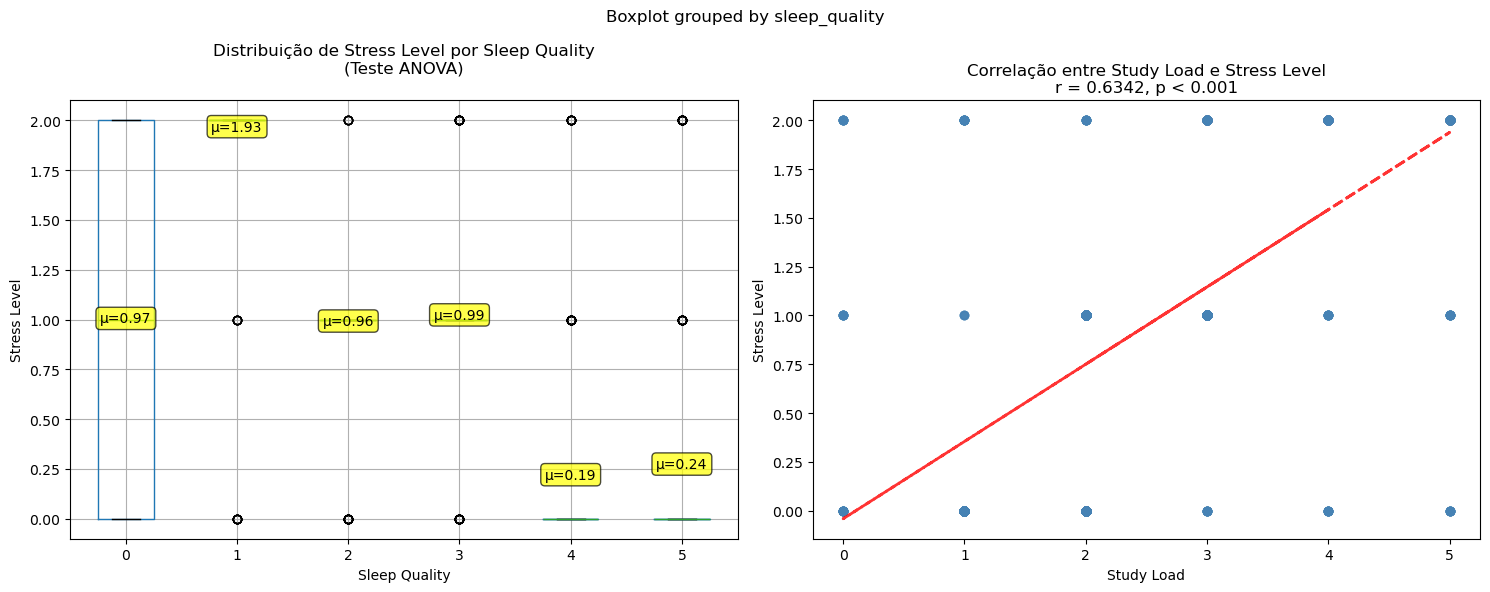

In [8]:
# Visualizações para complementar a análise
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Boxplot para ANOVA (stress_level por sleep_quality)
df.boxplot(column='stress_level', by='sleep_quality', ax=ax1)
ax1.set_title('Distribuição de Stress Level por Sleep Quality\n(Teste ANOVA)', fontsize=12, pad=20)
ax1.set_xlabel('Sleep Quality')
ax1.set_ylabel('Stress Level')

# Adicionar médias no boxplot
for i in sorted(df['sleep_quality'].unique()):
    media = df[df['sleep_quality'] == i]['stress_level'].mean()
    ax1.text(i+1, media, f'μ={media:.2f}', ha='center', va='bottom', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Gráfico 2: Scatter plot para correlação
ax2.scatter(df['study_load'], df['stress_level'], alpha=0.6, color='steelblue')
ax2.set_title(f'Correlação entre Study Load e Stress Level\nr = {correlation_coef:.4f}, p < 0.001', fontsize=12)
ax2.set_xlabel('Study Load')
ax2.set_ylabel('Stress Level')

# Adicionar linha de regressão
z = np.polyfit(df['study_load'], df['stress_level'], 1)
p = np.poly1d(z)
ax2.plot(df['study_load'], p(df['study_load']), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()

In [9]:
print("="*80)
print("RESUMO FINAL DOS TESTES DE HIPÓTESE")
print("="*80)

print("\n📊 HIPÓTESE 2 - ANOVA (Sleep Quality vs Stress Level):")
print("✅ RESULTADO: SIGNIFICATIVO")
print(f"   • F-statistic: {f_stat:.4f}")
print(f"   • p-valor: {p_value_anova:.2e}")
print("   • CONCLUSÃO: A qualidade do sono afeta significativamente o nível de estresse")
print("   • OBSERVAÇÃO: Sleep Quality = 1 tem a maior média de stress (1.93)")
print("   • OBSERVAÇÃO: Sleep Quality = 4 e 5 têm as menores médias de stress (~0.2)")

print("\n📈 HIPÓTESE 3 - Correlação de Pearson (Study Load vs Stress Level):")
print("✅ RESULTADO: SIGNIFICATIVO")
print(f"   • Coeficiente de correlação: {correlation_coef:.4f}")
print(f"   • p-valor: {p_value_corr:.2e}")
print(f"   • R² (variância explicada): {r_squared:.1%}")
print("   • CONCLUSÃO: Existe correlação positiva moderada e significativa")
print("   • INTERPRETAÇÃO: Maior carga de estudos está associada a maior nível de estresse")

print("\n🎯 AVALIAÇÃO GERAL DOS TESTES:")
print("✅ AMBOS os testes de hipótese foram MUITO VÁLIDOS e revelaram insights importantes:")
print("   1. A qualidade do sono é um fator crítico para o nível de estresse")
print("   2. A carga de estudos tem impacto direto e mensurável no estresse")
print("   3. Os resultados são estatisticamente robustos (p < 0.001 em ambos)")
print("   4. Os efeitos são praticamente significativos (não apenas estatisticamente)")

print("\n💡 RECOMENDAÇÕES BASEADAS NOS RESULTADOS:")
print("   • Programas de melhoria da qualidade do sono podem reduzir significativamente o estresse")
print("   • Gestão equilibrada da carga de estudos é fundamental para o bem-estar")
print("   • Intervenções preventivas devem focar simultaneamente em sono e carga acadêmica")

RESUMO FINAL DOS TESTES DE HIPÓTESE

📊 HIPÓTESE 2 - ANOVA (Sleep Quality vs Stress Level):
✅ RESULTADO: SIGNIFICATIVO
   • F-statistic: 517.1504
   • p-valor: 3.94e-285
   • CONCLUSÃO: A qualidade do sono afeta significativamente o nível de estresse
   • OBSERVAÇÃO: Sleep Quality = 1 tem a maior média de stress (1.93)
   • OBSERVAÇÃO: Sleep Quality = 4 e 5 têm as menores médias de stress (~0.2)

📈 HIPÓTESE 3 - Correlação de Pearson (Study Load vs Stress Level):
✅ RESULTADO: SIGNIFICATIVO
   • Coeficiente de correlação: 0.6342
   • p-valor: 8.45e-125
   • R² (variância explicada): 40.2%
   • CONCLUSÃO: Existe correlação positiva moderada e significativa
   • INTERPRETAÇÃO: Maior carga de estudos está associada a maior nível de estresse

🎯 AVALIAÇÃO GERAL DOS TESTES:
✅ AMBOS os testes de hipótese foram MUITO VÁLIDOS e revelaram insights importantes:
   1. A qualidade do sono é um fator crítico para o nível de estresse
   2. A carga de estudos tem impacto direto e mensurável no estresse
 